<a href="https://colab.research.google.com/github/parika8ec-hub/DA_AI_Project1_Stock_Data/blob/main/Project1_BasicEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task-1: Data Collection


In [2]:
#Import library
import pandas as pd # Pandas: data manipulation and analysis (Pandas Development Team, 2024)
import numpy as np # NumPy: numerical computing and array operations (Harris et al., 2020)
import matplotlib.pyplot as plt # Matplotlib: data visualization and plotting (Hunter, 2007)
import seaborn as sns # Seaborn: statistical data visualization built on Matplotlib (Waskom, 2021)

In [3]:
#Load historical stocks data
# Source: Pandas Development Team (2024) - https://pandas.pydata.org/docs/
past_stocks = pd.read_csv("historical_stocks.csv")
#Display few rows of data
print('Few rows of historical stocks data:')
print(past_stocks.head())
#Display information of data
print('\nInformation of data:')
print(past_stocks.info())

print('-'*75)

#Load historical stock's price data
# Source: Pandas Development Team (2024) - https://pandas.pydata.org/docs/
past_stock_prices = pd.read_csv("historical_stock_prices.csv")
#Display few rows of data
print("\nFew rows of historical stock's price data:")
print(past_stock_prices.head())
#Display information of data
print('\nInformation of data:')
print(past_stock_prices.info())

Few rows of historical stocks data:
  ticker exchange                                    name             sector  \
0    PIH   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
1  PIHPP   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
2   TURN   NASDAQ                180 DEGREE CAPITAL CORP.            FINANCE   
3   FLWS   NASDAQ                 1-800 FLOWERS.COM, INC.  CONSUMER SERVICES   
4   FCCY   NASDAQ           1ST CONSTITUTION BANCORP (NJ)            FINANCE   

                     industry  
0  PROPERTY-CASUALTY INSURERS  
1  PROPERTY-CASUALTY INSURERS  
2  FINANCE/INVESTORS SERVICES  
3      OTHER SPECIALTY STORES  
4        SAVINGS INSTITUTIONS  

Information of data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ticker    6460 non-null   object
 1   exchange  6460 non-null   object
 2   name  

# Task-2: Data Cleaning

**i) Identify and Handle Missing Values:**

**Missing Value Filling Strategy:**

- Missing values were handled using a structured time-series and statistical approach.
- Categorical variables (sector, industry) were filled with “Unknown” to avoid data loss.

- Stock price fields were imputed using logical market relationships as below.
- An open was filled using previous close value against ticker.
- A close using next open or missing value row open value against ticker.
- A low using open and high using close of missing row.
- Missing adj_close and volume values were filled using the median per ticker to reduce outlier impact.
- Missing dates were reconstructed using the next valid trading day of same ticker while skipping weekends to maintain time-series continuity.

**Example:**
Missing value found at index at 1335625 and missing data of it as below.

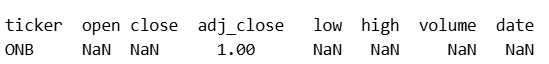

Display last 3 rows of ONB ticker with missing value index:
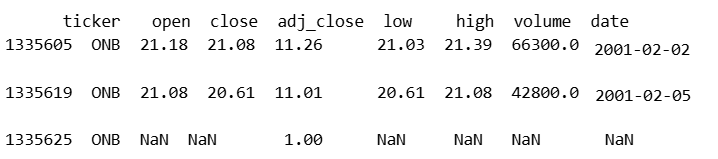

Updated missing values row:

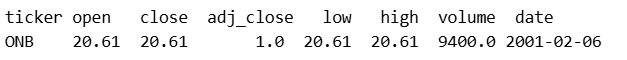

In [4]:
# Check Missing Values in historical stocks dataset
# Source: Pandas Development Team (2024) - https://pandas.pydata.org/docs/
print('Check missing values in historical stocks data:')
print('-'*45)
print(past_stocks.isnull().sum())

#Fill missing values of industry and sector column by Unknown
# Strategy: Replace missing values with "Unknown"
# Source: Common EDA preprocessing practice (Kaggle EDA workflows)
past_stocks.fillna({'sector': 'Unknown','industry':'Unknown'}, inplace=True)

#Verify missing values
print('\nAfter filling missing values, count of missing values in historical stocks data: ',past_stocks.isnull().sum().sum())

Check missing values in historical stocks data:
---------------------------------------------
ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64

After filling missing values, count of missing values in historical stocks data:  0


In [5]:
# Check Missing Values in historical stock's price dataset
# Source: Pandas Development Team (2024) - https://pandas.pydata.org/docs/
print("Check missing values in historical stock's price data:")
print('-'*45)
print(past_stock_prices.isnull().sum())

Check missing values in historical stock's price data:
---------------------------------------------
ticker       0
open         0
close        0
adj_close    0
low          0
high         1
volume       1
date         1
dtype: int64


In [6]:
'''
Note:
The dataset sometimes shows missing values and sometimes shows no missing values. Therefore, this code is written to check and handle missing values only when they are present.
'''

#Check if dataset contains missing values or not
# Source: Pandas Development Team (2024) - https://pandas.pydata.org/docs/
if past_stock_prices.isnull().sum().any()==True:

  # Display rows containing missing values along with their previous and next rows
  print('-'*45)
  #Find the index of missing rows
  missing_indices = past_stock_prices[past_stock_prices.isnull().any(axis=1)].index
  #Find the unique ticker of missing rows
  unique_tickers=past_stock_prices[past_stock_prices.isnull().any(axis=1)]['ticker'].unique()

  #Loop through all missing values index
  for idx in missing_indices:
      print(f"\nMissing value found at index: {idx}")
      print('\nMissing values row with preceding and following rows:')
      print(past_stock_prices.loc[idx-1:idx+1])
      print()

      # Display last 3 rows of ticker of missing values index
      ticker=past_stock_prices.loc[idx, 'ticker']#find ticker value of missing value index
      print('\nDisplay last 3 rows of ticker of missing values index:',idx)
      print('-'*45)
      print(past_stock_prices[past_stock_prices['ticker']==ticker].tail(3))

      # filter same ticker and only rows before missing index
      prev_row = past_stock_prices[(past_stock_prices['ticker'] == ticker) & (past_stock_prices.index < idx)].tail(1)

      # Handling missing dates
      #-----------------------------------------------------------------------
      # Source: Time-series preprocessing best practices (Kaggle EDA workflows)
      # previous valid date
      prev_date = prev_row['date'].iloc[0] #take date of previous row of missing value index

      prev_date = pd.to_datetime(prev_date)#convert previous date into date format

      # add 1 day in previous date
      new_date = prev_date + pd.Timedelta(days=1)

      # skip weekends, if present
      while new_date.weekday() in [5, 6]:
          new_date += pd.Timedelta(days=1)

      # fill missing date
      past_stock_prices.loc[idx, 'date'] = new_date.date()


      # Handling missing numeric values
      #------------------------------------------------------------------
      #Fill open value of missing row using previous row close value of same ticker
      print('open:',pd.isna(past_stock_prices.iloc[idx]['open']),prev_row.index[0])
      if pd.isna(past_stock_prices.iloc[idx]['open']) and idx > 0:
          past_stock_prices.iloc[idx, past_stock_prices.columns.get_loc('open')] = past_stock_prices.iloc[prev_row.index[0]]['close']

      #Fill close value of missing row
      if pd.isna(past_stock_prices.iloc[idx]['close']):
        #Handle next row not found error
        try:
          #Take next row with same ticker of missing value
          next_row = past_stock_prices[(past_stock_prices['ticker'] == ticker) & (past_stock_prices.index > idx)].head(1)
          #Check if next row is present or not
          if not next_row.empty:
            next_index = next_row.index[0]#take index of next row
            #Fill close value of missing row using next row open value of same ticker
            past_stock_prices.iloc[idx, past_stock_prices.columns.get_loc('close')] = past_stock_prices.iloc[next_index]['open']
        except:
          print('No next row found')
          #Fill close value of missing row using open value of same row of same ticker
          past_stock_prices.iloc[idx, past_stock_prices.columns.get_loc('close')] = past_stock_prices.iloc[idx]['open']

      #Fill missing value of low with open value of same row
      if pd.isna(past_stock_prices.iloc[idx]['low']):
          past_stock_prices.iloc[idx, past_stock_prices.columns.get_loc('low')] = past_stock_prices.iloc[idx]['open']

      #Fill missing value of high with close value of same row
      if pd.isna(past_stock_prices.iloc[idx]['high']):
          past_stock_prices.iloc[idx, past_stock_prices.columns.get_loc('high')] = past_stock_prices.iloc[idx]['close']


  #Take each adj_close and volume columns to fill values
  # Source: Standard EDA imputation techniques (Pandas & Kaggle practices)
  for col in ['adj_close','volume']:
      # Fill missing values in each column using median of that column for each ticker group
      past_stock_prices[col] = past_stock_prices.groupby('ticker')[col].transform(lambda x: x.fillna(x.median()))

  # Display all updated rows
  print('\nUpdated missing values row:')
  print('-'*45)
  print(past_stock_prices.loc[missing_indices])

else:
  print("\nNo missing values found in historical stock's price data")

---------------------------------------------

Missing value found at index: 1735505

Missing values row with preceding and following rows:
        ticker      open     close  adj_close      low      high    volume  \
1735504    OII   1.78125   1.78125   1.571386  1.78125  1.796875  221600.0   
1735505    IQI  14.05000  14.01000   5.367072  1.00000       NaN       NaN   

               date  
1735504  1989-09-01  
1735505         NaN  


Display last 3 rows of ticker of missing values index: 1735505
---------------------------------------------
        ticker   open  close  adj_close    low   high   volume        date
1735496    IQI  14.33  14.05   5.382392  14.00  14.33  70800.0  2003-07-17
1735497    IQI  14.05  14.09   5.397721  13.96  14.13  38900.0  2003-07-18
1735505    IQI  14.05  14.01   5.367072   1.00    NaN      NaN         NaN
open: False 1735497

Updated missing values row:
---------------------------------------------
        ticker   open  close  adj_close  low   high  

**ii) Idenytify and handle duplicates:**


In [7]:
# Check duplicate values
# Source: Pandas Development Team (2024) - https://pandas.pydata.org/docs/
print('Duplicate rows count in dataset1:')
print('-'*45)
print(past_stocks.duplicated().sum())#find duplicates
print('\nDuplicate rows count in dataset2:')
print('-'*45)
print(past_stock_prices.duplicated().sum())#find duplicates

'''
Note:
The dataset is large and every run shows different result. Therefore, this code is written to handle duplicates values only when they are present.
'''

#Remove duplicate values, if avaialble
# Source: Standard data cleaning practice in Pandas EDA workflows
if past_stocks.duplicated().sum()>0 or past_stock_prices.duplicated().sum()>0:#check duplicate rows count
  past_stocks.drop_duplicates(inplace=True)#remove duplicates
  print('\nAfter removing duplicate values, shape of dataset1: ',past_stocks.shape)
  past_stock_prices.drop_duplicates(inplace=True)#remove duplicates
  print('\nAfter removing duplicate values, shape of dataset2: ',past_stock_prices.shape)
else:
  print('\nNo duplicate values found in both datasets.')

Duplicate rows count in dataset1:
---------------------------------------------
0

Duplicate rows count in dataset2:
---------------------------------------------
0

No duplicate values found in both datasets.


**iii) Convert the Date column to a datetime format and set it as the index in stock prices dataset**


In [8]:
#Convert date column of stock price dataset to datatime format
# Source: Pandas Development Team (2024) - https://pandas.pydata.org/docs/
past_stock_prices['date'] = pd.to_datetime(past_stock_prices['date'], errors='coerce')

In [9]:
#Set date column as index of stock price dataset
# Source: Pandas Development Team (2024) - https://pandas.pydata.org/docs/
past_stock_prices.set_index('date', inplace=True)

#Verify dataset after cleaning
print(past_stock_prices.info())
print('\n Few rows of updated dataset:')
print(past_stock_prices.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1735506 entries, 2013-05-08 to 2003-07-21
Data columns (total 7 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     object 
 1   open       float64
 2   close      float64
 3   adj_close  float64
 4   low        float64
 5   high       float64
 6   volume     float64
dtypes: float64(6), object(1)
memory usage: 105.9+ MB
None

 Few rows of updated dataset:
           ticker   open  close  adj_close    low   high     volume
date                                                               
2013-05-08    AHH  11.50  11.58   8.493155  11.25  11.68  4633900.0
2013-05-09    AHH  11.66  11.55   8.471151  11.50  11.66   275800.0
2013-05-10    AHH  11.55  11.60   8.507822  11.50  11.60   277100.0
2013-05-13    AHH  11.63  11.65   8.544494  11.55  11.65   147400.0
2013-05-14    AHH  11.60  11.53   8.456484  11.50  11.60   184100.0


# Task-3: Data Segmentation by Decade for Stock Prices Dataset

In [10]:
# Source: Pandas Development Team (2024) - https://pandas.pydata.org/docs/
# Create a new column that groups stock prices into decades based on the year (e.g., 1990, 2000, 2010)
past_stock_prices['price_decade'] = (past_stock_prices.index.year // 10) * 10

decade_data = {}#create empty dictionary, which is used to store decade with its value from price_decade column

# Split the dataset into separate DataFrames for each decade based on the 'price_decade' column
for decade in past_stock_prices['price_decade'].unique():#take unique decade values
    #filter data against decade values and store it against decade in the decade_data dictionary
    decade_data[decade] = past_stock_prices[past_stock_prices['price_decade'] == decade]

print('Each decade with its dataframe shape:')
#Create a new dataframe to store data of each decade
for decade, decade_df in decade_data.items():
    print(f"{decade}: {decade_df.shape}")#display each decade dataframe shape

print('\nAll decade with their years:')
# Extract year from the datetime index and store it in a new column
past_stock_prices['year'] = past_stock_prices.index.year

# Group data by decade and get unique years present in each decade
decade_years = past_stock_prices.groupby('price_decade')['year'].unique()

# Loop through each decade and its corresponding years
for decade, years in decade_years.items():

    # Convert NumPy integers to normal integers and sort the years
    clean_years = sorted([int(y) for y in years])

    # Print each decade with the list of years it contains
    print(f"{decade}: {clean_years}")

#Drop year column from dataset for further tasks
past_stock_prices=past_stock_prices.drop(columns=['year'])

Each decade with its dataframe shape:
2010: (769783, 8)
2000: (533706, 8)
1990: (288302, 8)
1980: (136506, 8)
1970: (7209, 8)

All decade with their years:
1970: [1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979]
1980: [1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989]
1990: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999]
2000: [2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009]
2010: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]


# Task-4: Exploratory Data Analysis by Decade

**i)Merge Dataframe:**

In [11]:
#Merge the stock_prices dataset with the stock dataset using the ticker and sector key to include sector information with the stock prices
# Source: Pandas Development Team (2024) - https://pandas.pydata.org/docs/
# Technique based on standard data integration practices in EDA (Kaggle workflows)
merged_df = past_stock_prices.reset_index().merge(past_stocks[['ticker','sector']],on='ticker',how='left')
print('Few rows of merged dataframe:')
print(merged_df.head())#display merged dataframe

Few rows of merged dataframe:
        date ticker   open  close  adj_close    low   high     volume  \
0 2013-05-08    AHH  11.50  11.58   8.493155  11.25  11.68  4633900.0   
1 2013-05-09    AHH  11.66  11.55   8.471151  11.50  11.66   275800.0   
2 2013-05-10    AHH  11.55  11.60   8.507822  11.50  11.60   277100.0   
3 2013-05-13    AHH  11.63  11.65   8.544494  11.55  11.65   147400.0   
4 2013-05-14    AHH  11.60  11.53   8.456484  11.50  11.60   184100.0   

   price_decade   sector  
0          2010  FINANCE  
1          2010  FINANCE  
2          2010  FINANCE  
3          2010  FINANCE  
4          2010  FINANCE  


In [12]:
# Save merged dataframe to CSV file
# Source: Pandas Development Team (2024) - https://pandas.pydata.org/docs/
merged_df.to_csv("merged_stock_data.csv", index=False)

print("Merged dataset successfully saved as 'merged_stock_data.csv'")

Merged dataset successfully saved as 'merged_stock_data.csv'


**ii) For each decade DataFrame, calculate summary statistics:**


In [13]:
# Source: Pandas Development Team (2024) - https://pandas.pydata.org/docs/
# Method based on standard EDA statistical analysis practices (Kaggle workflows)
summary_stats = {}#used to store decade with its summary statistics
#Take each decade and dataframe of it
for decade, df in decade_data.items():
    #Calculate summary statistics of numerical columns of each decade
    summary = df[['open','high','low','close','volume']].agg(['mean','median','std'])
    summary_stats[decade] = summary #store decade with its summary statistics
    #Display summary result
    print(f"\nSummary Statistics for {decade}s:")
    print(summary)


Summary Statistics for 2010s:
             open       high        low      close        volume
mean    37.776632  38.258187  37.254596  37.755454  3.396811e+06
median  20.320000  20.600000  20.030001  20.330000  1.494000e+05
std     92.547837  94.685683  89.374358  91.808456  5.953589e+07

Summary Statistics for 2000s:
                open          high           low         close        volume
mean      669.048176    684.297319    654.880899    670.055424  3.384999e+06
median     15.515000     15.791667     15.250000     15.520000  1.437000e+05
std     13579.271894  13888.671278  13327.461128  13635.561838  2.663158e+07

Summary Statistics for 1990s:
               open         high          low        close        volume
mean      51.040216    52.623388    49.488483    51.028129  1.491192e+06
median     9.765625     9.937500     9.636699     9.777778  6.750000e+04
std     2020.576847  2100.537331  1947.342607  2023.256090  1.064558e+07

Summary Statistics for 1980s:
               o

**Statistics Summary Insights:**

Note: The below insights are based on above result.

**1970s:**

The 1970s had low stock prices with an average close of 3.62 and relatively stable volatility (std = 3.64). Trading volume was also low, indicating limited market participation.

**1980s:**

Average closing prices increased to 23.67, showing market growth. Volatility rose significantly (std = 1840.05), indicating higher price fluctuations. Trading volume also increased, reflecting growing activity.

**1990s:**

Stock prices continued to rise with an average close of 51.03. Trading volume increased to 1.49 million, showing stronger market participation, though volatility remained high.

**2000s:**

The 2000s showed very high average prices (670.06) and extreme volatility (std = 13635.56). Large gaps between mean and median indicate strong outliers. Trading volume was also high, reflecting intense but unstable market behavior.

**2010s:**

Prices stabilized with an average close of 37.76, while volatility decreased (std = 91.81). Trading volume peaked at 3.40 million, showing strong and consistent market participation.

**iii) Create visualizations for each decade:**

/tmp/ipykernel_22581/3518565502.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = df['close'].resample('M').mean()
/tmp/ipykernel_22581/3518565502.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = df['close'].resample('M').mean()
/tmp/ipykernel_22581/3518565502.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = df['close'].resample('M').mean()
/tmp/ipykernel_22581/3518565502.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = df['close'].resample('M').mean()
/tmp/ipykernel_22581/3518565502.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_close = df['close'].resample('M').mean()


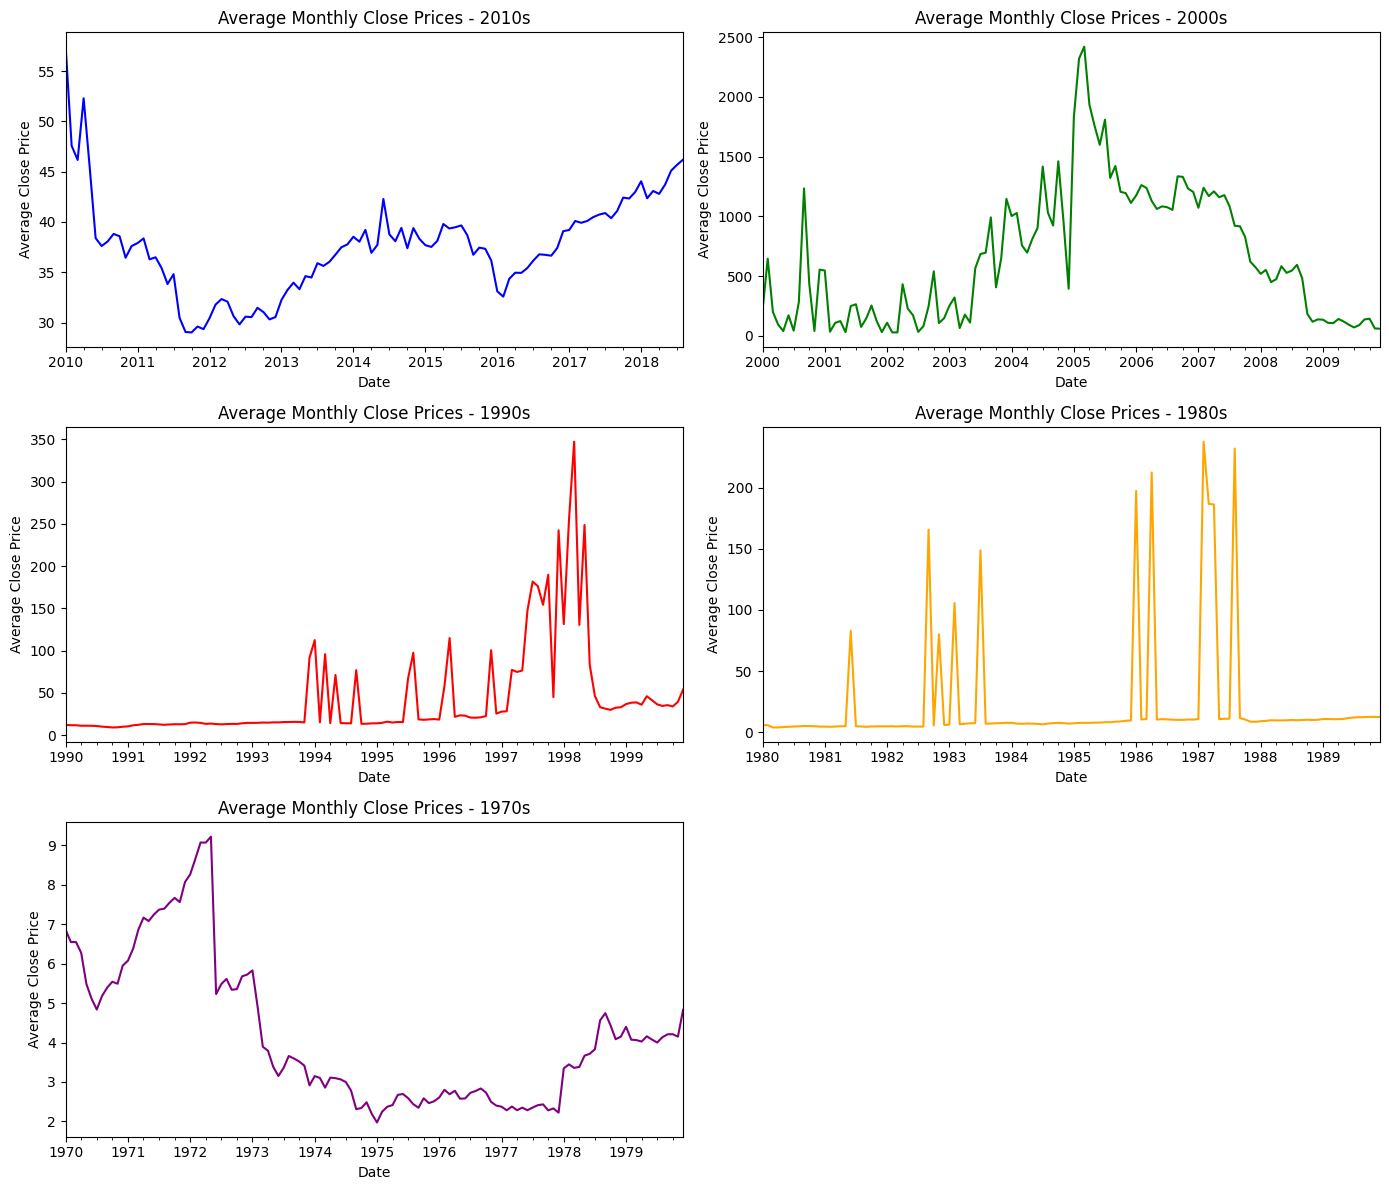

In [14]:
#Create time series plots for average monthly close prices for each decade
# Source: Matplotlib Documentation (Hunter, 2007)
# Source: Pandas Time-Series Resampling documentation (Pandas Development Team, 2024)
# Method based on standard financial EDA visualization practices (Kaggle workflows)

# Define colors for each decade plot
colors = ['blue', 'green', 'red', 'orange', 'purple']

# Create subplot layout with 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
# Convert axes into 1D array for easier iteration
axes = axes.flatten()

# Loop through each decade dataframe
for i, (decade, df) in enumerate(decade_data.items()):

    # Calculate average monthly close prices
    monthly_close = df['close'].resample('M').mean()

    # Plot on subplot
    monthly_close.plot(ax=axes[i],color=colors[i])

    # Add title and labels
    axes[i].set_title(f'Average Monthly Close Prices - {decade}s')
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Average Close Price")

# Remove extra empty subplot
fig.delaxes(axes[-1])
# Adjust spacing between plots
plt.tight_layout()
plt.show()#display plots

**Average Monthly Close Price Trend Insights:**

Note: The below insights are based on above plot.

- **1970s:** Stock prices show relatively low values with small fluctuations. The trend starts moderately high, drops in the mid-1970s and then gradually recovers toward the end of the decade. Overall, the market appears stable with a narrow price range.

- **1980s:** This decade shows clear signs of volatility with several sharp spikes in prices. While some periods remain stable, sudden upward movements indicate irregular trading behavior and market sensitivity.

- **1990s:** A strong upward trend is visible, especially in the late 1990s where prices rise sharply and peak around 1997-1998. This suggests rapid market expansion and increased investor activity, likely linked to economic growth and the tech-driven market boom. Volatility increases compared to earlier decades, but growth dominates the overall pattern.

- **2000s:** This decade exhibits the highest volatility. Prices fluctuate heavily with multiple spikes in the early 2000s, reaching an extreme peak around 2005, followed by a steep decline toward 2008-2009. This pattern reflects major market instability and a possible financial crisis impact.

- **2010s:** Prices are more stable compared to previous decades, with moderate fluctuations and a clearer long-term upward trend. There is a slight dip around 2011-2012, followed by consistent recovery and gradual growth toward 2018. Compared to earlier decades, the market appears more stable and less erratic, indicating improved market maturity and consistency.

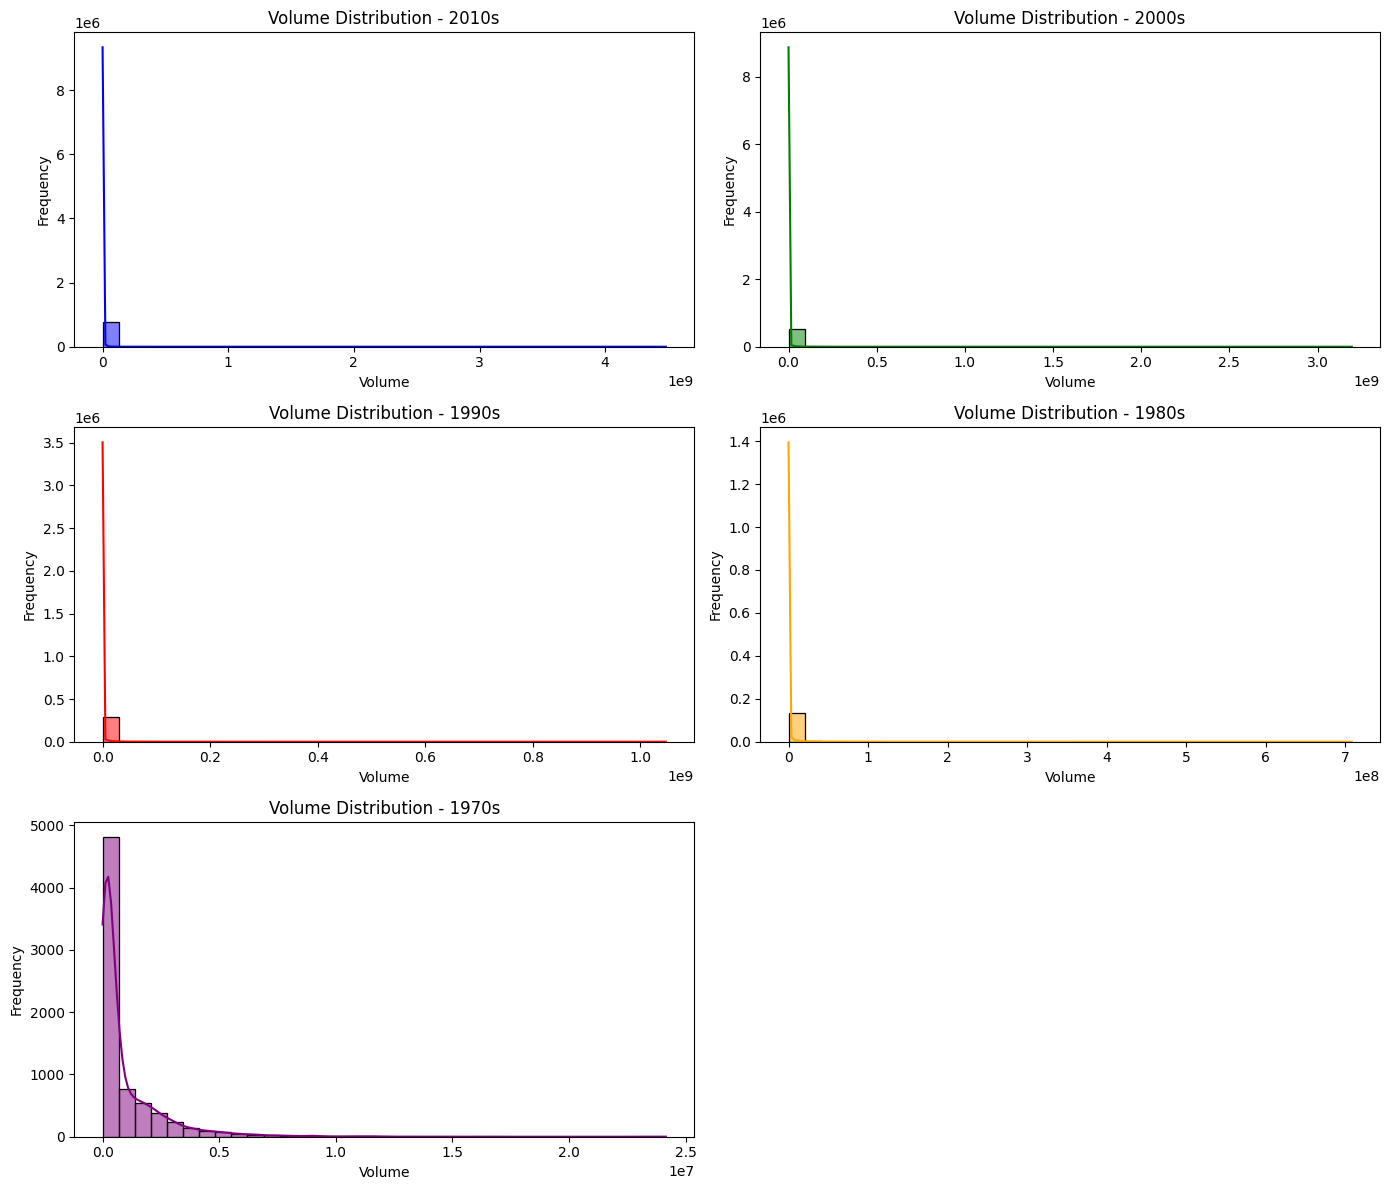

In [15]:
#Create histograms for Volume to analyze the distribution and any shifts over the decades
# Source: Seaborn Documentation (Waskom, 2021)
# Source: Matplotlib Documentation (Hunter, 2007)
# Source: Pandas documentation for data handling (Pandas Development Team, 2024)
# Based on standard EDA visualization practices for financial data (Kaggle workflows)
# Define colors for each decade plot
colors = ['blue', 'green', 'red', 'orange', 'purple']

# Create subplot layout with 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Convert axes into 1D array for easier iteration
axes = axes.flatten()

# Loop through each decade dataset
for i, (decade, df) in enumerate(decade_data.items()):

    # Create histogram with different colors
    sns.histplot(df['volume'], bins=35, kde=True, color=colors[i], ax=axes[i])

    # Add title and axis labels
    axes[i].set_title(f'Volume Distribution - {decade}s')
    axes[i].set_xlabel("Volume")
    axes[i].set_ylabel("Frequency")

# Remove extra empty subplot
fig.delaxes(axes[-1])

# Adjust spacing between plots
plt.tight_layout()

plt.show() # display plots

**Volume Distribution Pattern Insights:**

Note: The below insights are based on above plot.

- All decades show right-skewed distributions, meaning most trading volumes were low to moderate, while a few days had extremely high trading volumes.
- Trading volume increased significantly from the 1970s to 2010s, showing higher market participation over time.
- The 2000s and 2010s contain extreme volume outliers, suggesting heavy trading activity during major market events.

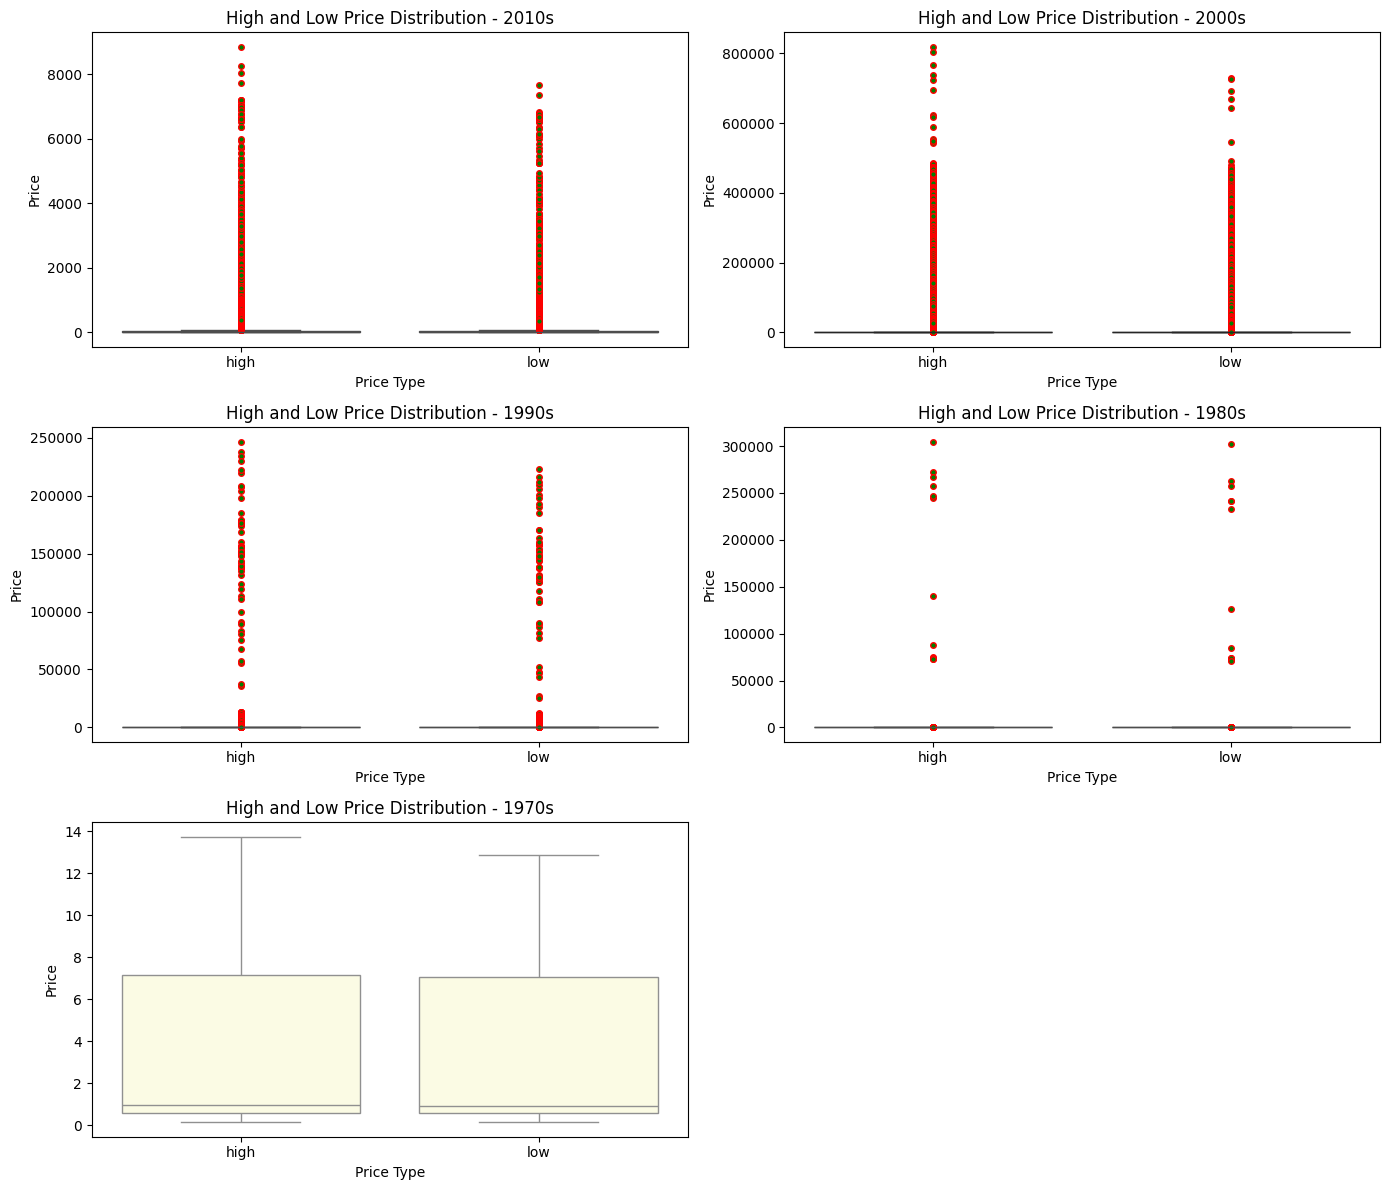

In [16]:
#Box plots for the High and Low prices to examine the range and presence of outliers
# Source: Seaborn Documentation (Waskom, 2021)
# Source: Matplotlib Documentation (Hunter, 2007)
# Source: Pandas Documentation (Pandas Development Team, 2024)
# Based on standard financial EDA practices for outlier detection (Kaggle workflows)
# Define colors for each decade plot
colors = ['blue', 'green', 'red', 'orange', 'lightyellow']

# Customize outlier markers
flier_props = dict(marker='o',markerfacecolor='green',markeredgecolor='red',markersize=4)

# Create subplot layout with 3 rows and 2 columns
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Convert axes into 1D array for easy looping
axes = axes.flatten()

# Loop through each decade dataset
for i, (decade, df) in enumerate(decade_data.items()):

    # Create box plot for high and low prices
    sns.boxplot(data=df[['high', 'low']],palette=[colors[i], colors[i]],ax=axes[i], flierprops=flier_props,)

    # Add title and axis labels
    axes[i].set_title(f'High and Low Price Distribution - {decade}s')
    axes[i].set_xlabel("Price Type")
    axes[i].set_ylabel("Price")

# Remove extra empty subplot
fig.delaxes(axes[-1])

# Adjust spacing between plots
plt.tight_layout()

plt.show()# display plots

**High and Low Price Box Plot Analysis:**

Note: The below insights are based on above plot.

- 1970s:Price ranges were smaller with few or minimal outliers, indicating relatively stable stock prices and limited variation between high and low prices.

- 1980s-2010s: The number of outliers increased significantly, showing larger price fluctuations.
- The 1990s and 2000s show extremely high outliers, suggesting the presence of very high-priced stocks or unusual market events.
- The spread between high and low prices widened over time, indicating increased market volatility in later decades.

# Task-5: Comparative Analysis

Note: The task-5 report is based on above insights and results.

**Decade Comparison of Stock Market Trends and Statistics Summary:**

**Overall Market Evolution Across Decades:**

The analysis highlights a clear long-term transformation in stock market behavior from the 1970s to the 2010s. Over time, the market evolves from a relatively stable, low-activity system into a highly liquid but increasingly complex and volatile financial environment.

**Decade-by-Decade Comparison:**

- From the 1970s to the 2010s, the stock market shows a clear evolution in terms of growth, volatility and trading activity.

- In the 1970s, the market is characterized by low stock prices (mean close = 3.62), limited trading activity and relatively stable volatility (std = 3.64), with price movements remaining within a narrow range, indicating a less developed and low-participation financial system.

- During the 1980s, the market begins to expand, as average prices rise significantly (mean close = 23.67) and trading activity increases; however, volatility also rises, reflecting more frequent price fluctuations and growing market sensitivity.

- In the 1990s, the market enters a strong growth phase, with higher average prices (mean close = 51.03) and a substantial increase in trading volume (= 1.49 million), while investor participation strengthens and price trends show sustained upward momentum despite continued volatility.

- In the 2000s, the market experiences extreme instability, with very high average prices (mean close = 670.06) alongside extremely large volatility (std = 13,635) and a strong divergence between mean and median values indicating heavy skewness and major outliers; this reflects pronounced boom-and-bust cycles influenced by major financial disruptions such as the dot-com crash and the 2008 financial crisis, with trading activity remaining high but highly erratic.

- Finally, in the 2010s, the market transitions toward maturity and relative stabilization, as average prices moderate (mean close = 37.76) and volatility declines compared to the 2000s (std = 91.81), though still higher than earlier decades, while trading volume peaks (= 3.40 million), indicating strong, consistent participation within a more liquid and globally integrated financial market.

**Key Cross-Decade Trends:**

- Overall, the long-term trends in the stock market reveal consistent structural changes across decades.
- Stock prices generally increase from the 1970s through the 2000s, followed by a normalization in the 2010s, suggesting a correction phase after periods of rapid growth and heightened instability.
- Trading volume shows a steady upward trend throughout all decades, reflecting increasing investor participation, market accessibility and the globalization of financial systems.
- At the same time, volatility rises progressively over time, with early decades exhibiting relatively stable price movements while later decades particularly the 2000s show extreme fluctuations and heightened sensitivity to macroeconomic conditions.
- The impact of major financial shocks is especially evident in the 2000s, where events such as financial crises significantly distort price behavior, amplify volatility and generate extreme outliers in the data.
- Additionally, the distribution of both prices and trading volumes becomes increasingly right-skewed in later decades, indicating that a small number of extreme events or highly influential stocks contribute disproportionately to overall market movements.


**Interpretation of Stock Market Behavior Phases:**

1) Emerging Market Phase (1970s) as low activity, stable pricing and limited participation.
2) Growth Phase (1980s-1990s)as expanding prices, rising volume and increasing investor engagement.
3) Volatility Phase (2000s) as extreme fluctuations, market instability and crisis-driven behavior.
4) Maturity Phase (2010s) as high liquidity with improved stability and more consistent long-term trends.



**Overall Patterns and Anomalies Summary:**

- Stock prices show a general increase from the 1970s through the 2000s, followed by a noticeable normalization in the 2010s after the extreme values seen in the previous decade.
- Trading volumes consistently rise across all decades, with the highest levels observed in the 2010s, indicating steadily increasing investor participation and market activity over time.
- Volatility increases significantly from the 1980s onward, reaching extreme levels in the 2000s, where very large standard deviations and strong mean-median gaps highlight severe instability and market distortions.
- The 2010s reflect a more balanced phase, with reduced volatility compared to the 2000s and more consistent price behavior, despite maintaining high trading activity.
- Outliers become increasingly prominent from the 1980s onward, especially in the 1990s and 2000s, indicating growing market complexity, structural shifts and the influence of extreme market events.

**Conclusion**

Overall, the analysis shows that the stock market has evolved significantly over time. Early decades were relatively stable with lower activity, while later decades show higher trading volumes, increased complexity and greater volatility. The 2000s stand out as the most unstable period, while the 2010s indicate a shift toward more stable and mature market behavior.

**Code References:**

- Pandas Documentation: https://pandas.pydata.org/docs/
- Seaborn Documentation: https://seaborn.pydata.org/
- Matplotlib Documentation: https://matplotlib.org/
- Data manipulation techniques inspired by standard EDA practices in Kaggle notebooks: https://www.kaggle.com/code/imoore/intro-to-exploratory-data-analysis-eda-in-python
- Kaggle. (n.d.). Time-series data cleaning and exploratory data analysis notebooks. https://www.kaggle.com/code/imoore/intro-to-exploratory-data-analysis-eda-in-python
- Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90-95. https://doi.org/10.1109/MCSE.2007.55
- Waskom, M. L. (2021). seaborn: statistical data visualization. Journal of Open Source Software, 6(60), 3021. https://doi.org/10.21105/joss.03021